In [47]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np

import torch

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('utils.py'), ".."))
sys.path.append(parent_dir)
import utils as ut
import fc

In [48]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [49]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [50]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
table_dir = cwd.parent / 'data' / 'tables'
model_dir = cwd.parent / 'models'

In [51]:
tables = table_dir.rglob('*')
df = pd.concat((pd.read_csv(t) for t in tables), ignore_index=True)

ceers_flux = df.filter(regex='^FLUX_')
ceers_err = df.filter(regex='^FLUXERR_')
primer_flux = df.filter(regex='^f_f') * 10
primer_err = df.filter(regex='^e_f') * 10

df.drop((list(ceers_flux.columns) + list(primer_flux.columns)
         + list(ceers_err.columns) + list(primer_err.columns)),
         inplace=True, axis=1)

ceers_flux.rename(columns=lambda x: x.replace('FLUX_', 'F'), inplace=True)
primer_flux.rename(columns=lambda x: x.replace('f_f', 'F')[:-1], inplace=True)
ceers_err.rename(columns=lambda x: x.replace('FLUXERR_', 'E'), inplace=True)
primer_err.rename(columns=lambda x: x.replace('e_f', 'E')[:-1], inplace=True)

combined_flux = ceers_flux.combine_first(primer_flux)
combined_err = ceers_err.combine_first(primer_err)

combined_flux = combined_flux.mask(combined_flux <= 0.001, np.nan)
combined_err = combined_err.mask(combined_err <= 0.001, np.nan)
combined_flux = combined_flux.mask(combined_flux == -99, np.nan)
combined_err = combined_err.mask(combined_err == -99, np.nan)

df = pd.concat([df, np.log10(combined_flux), np.log10(combined_err)], axis=1)

In [53]:
in_features = ['beta', 'Av'] + list(combined_flux.columns)
out_feature = 'flag'

bad_av = df['Av'] == -99
bad_beta = df['beta'] == -99
df = df[~bad_beta | ~bad_av]

In [65]:
for col in combined_flux.columns:
    length = len(combined_flux[col].dropna())
    print(col, length)

F115 467
F150 469
F200 473
F277 483
F356 478
F410 471
F444 476
F606 382
F814 426
F105 35
F125 423
F140 347
F160 432
F435 197
F090 342


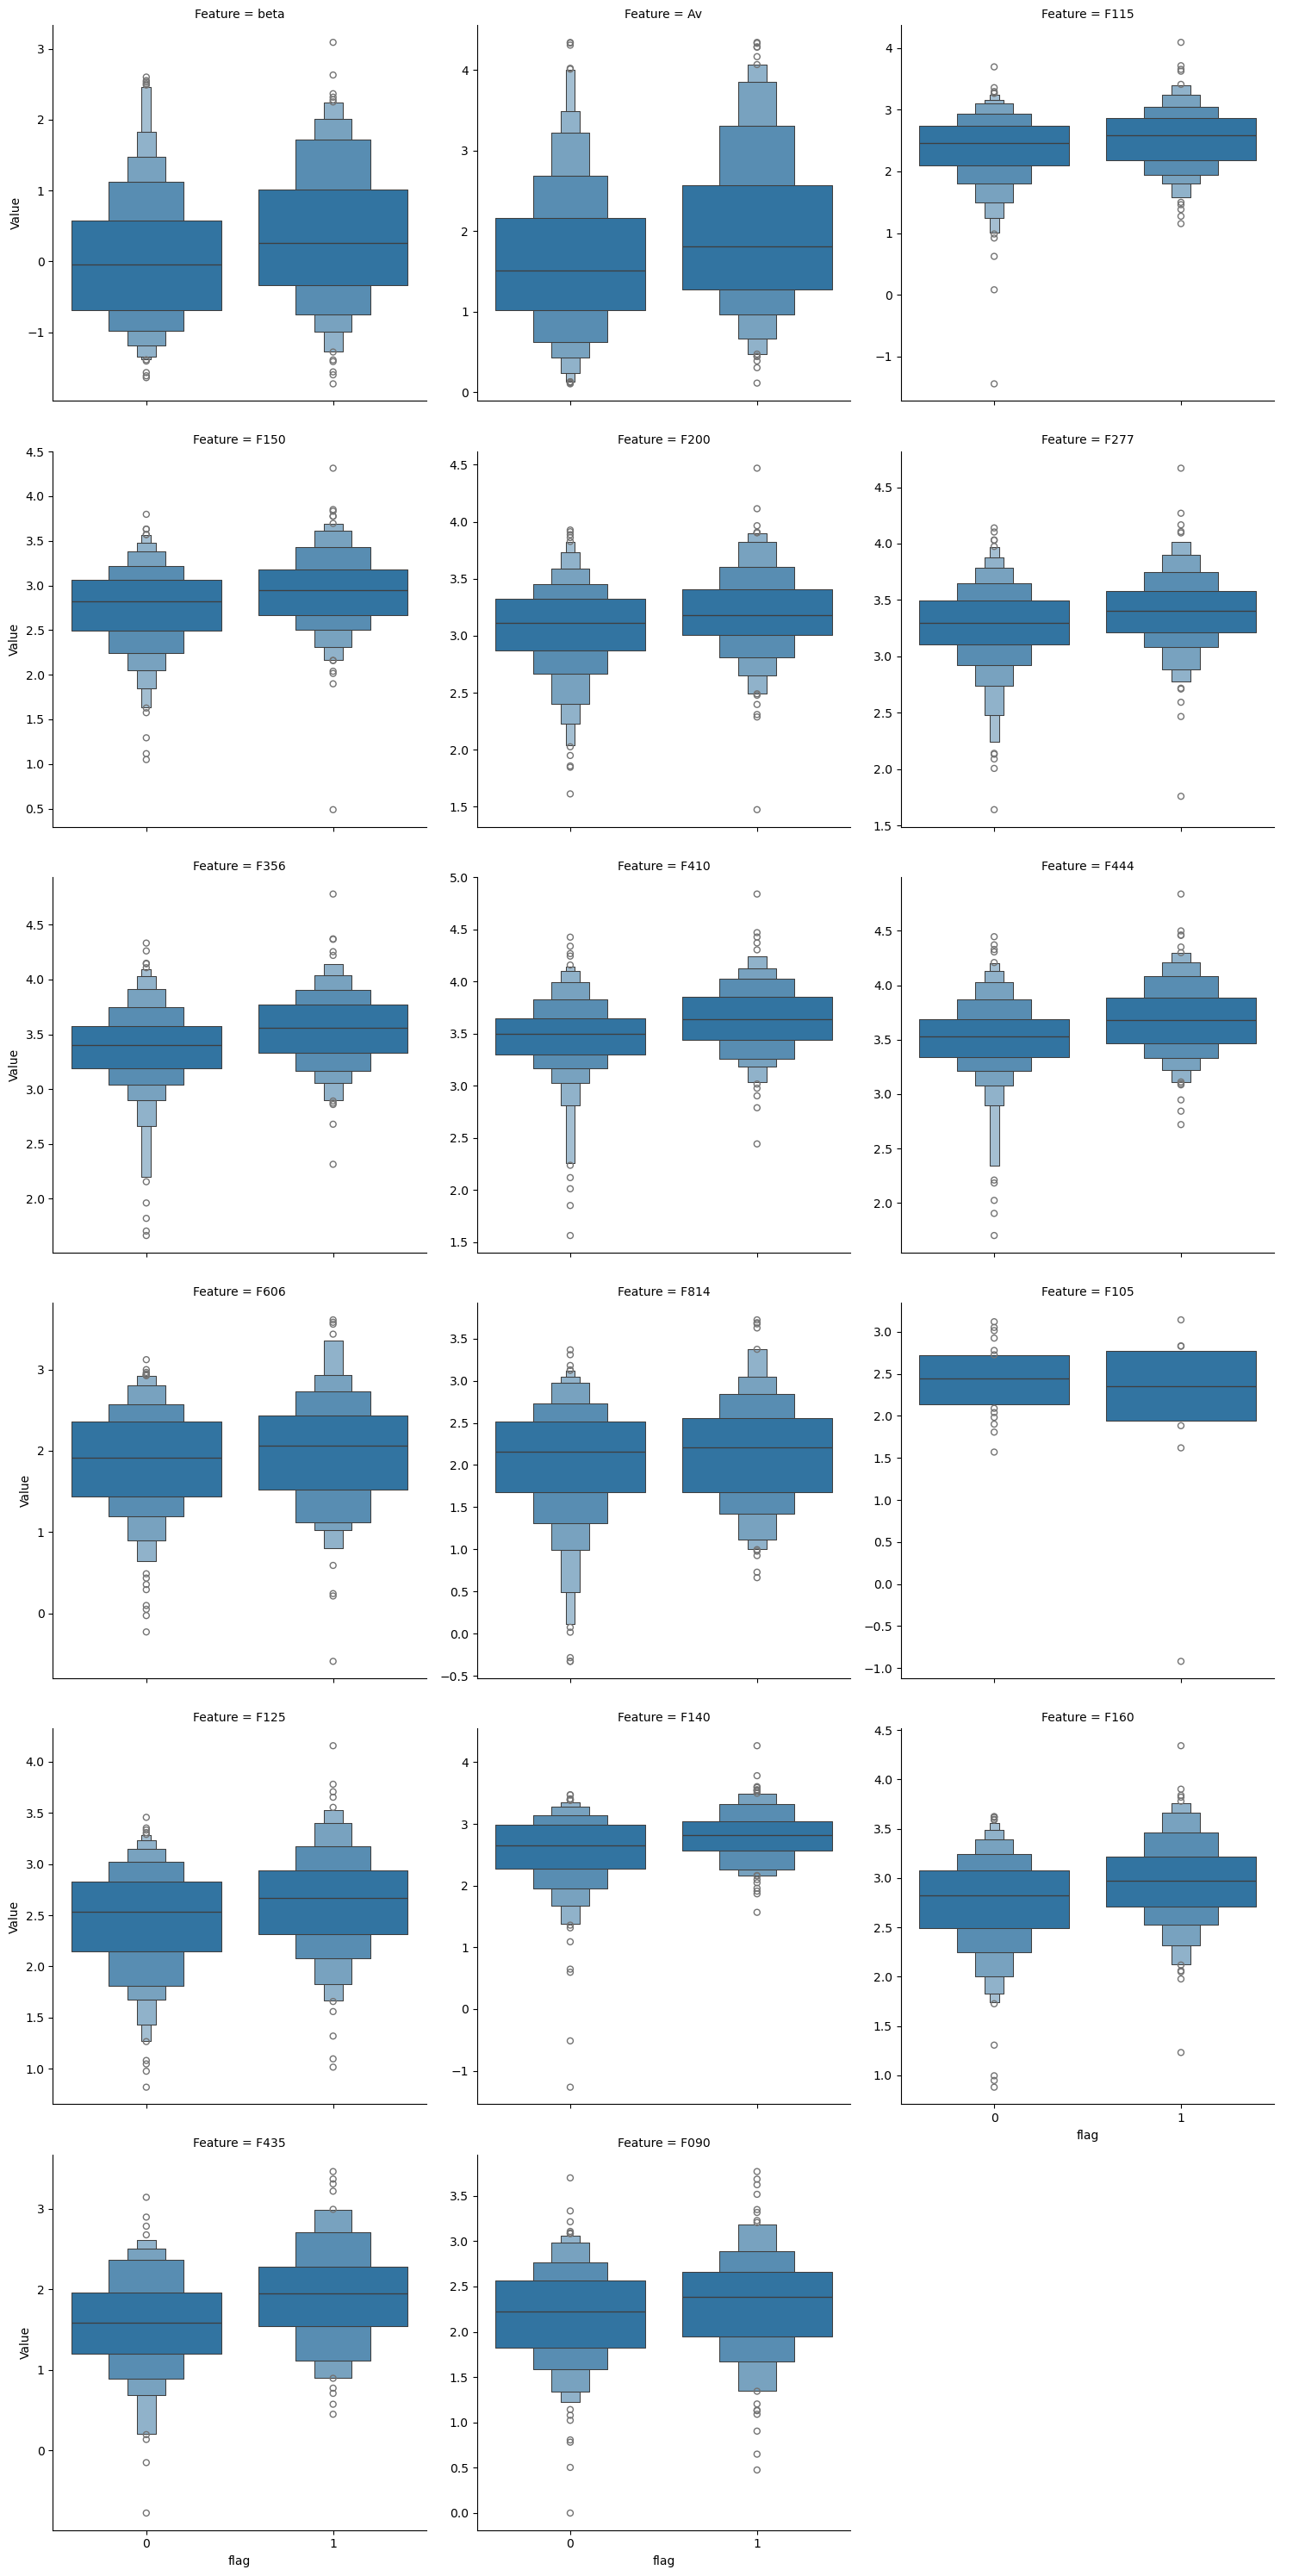

In [54]:
# melt -  basically expands df to each value of each in feature row has its own column
df_melted = pd.melt(df, id_vars=[out_feature], value_vars=in_features,
                    var_name='Feature', value_name='Value')

# plot them in the sad whsker way
g = sns.catplot(data=df_melted, x=out_feature, 
                y='Value', col='Feature', 
                kind='boxen', sharey=False, 
                col_wrap=3)

plt.show()

In [55]:
# helper function to plot a model
from pathlib import Path
def plot_loss(path, model, name=None):
    if name is None:
        name = Path(path).stem
    # load saved model
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    # plot training and validation loss
    plt.figure(figsize=(12, 8))
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("RMSE Loss")
    plt.title(name)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


In [56]:
params = {'num_outputs': 2,
          'dropout': 0.6,
          'scale': 32,
          'input_dim': 6}
model = fc.GalaxyClassifier(**params)
path = r'C:\Users\harty\Code\Galaxy-Classifier\Summer Research\models\fc\model_0.788.pth'

In [57]:
hist = True    
if hist:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
    from torch.utils.data import DataLoader

    model.eval()
    all_preds = [] # model outputs
    all_trues = [] # ground truths

    # set up batches for entire validation set
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=N_WORKERS)

    # predictions for entire validation set
    with torch.no_grad():
        for imgs, labels in val_loader:
            with torch.amp.autocast(DEVICE.type):
                outputs = model(imgs)
            all_preds.append(outputs.cpu().float().numpy())
            all_trues.append(labels.cpu().float().numpy())

    preds_matrix = np.vstack(all_preds)
    trues_matrix = np.vstack(all_trues)

    # get prediction residuals for each galaxy, then compute mean and stdev
    residuals = preds_matrix - trues_matrix 
    flattened_residuals = residuals.flatten()
    mean_val = np.mean(flattened_residuals)
    std_val = np.std(flattened_residuals)

    # plot histogram of residuals
    plt.figure()
    plt.hist(flattened_residuals, bins='fd', range=(-0.5, 0.5), color="blue")

    plt.title("Error Distribution")
    plt.xlabel("Residual Value")
    plt.ylabel("N")

    # show mean and std
    plt.text(0.25, plt.gca().get_ylim()[1] * 0.85, f"Mean: {mean_val:+.4f}", color="green")
    plt.text(0.25, plt.gca().get_ylim()[1] * 0.75, f"Std: {std_val:.4f}", color="orange")

    plt.tight_layout()
    plt.show()

NameError: name 'val_set' is not defined